In [10]:
import pandas as pd
import numpy as np

df = pd.read_csv("C:\\Users\\User\\Desktop\\developer survey ML project\\data\\survey_results_public.csv", low_memory=False)
print("Raw shape:", df.shape)   # (49191, 172)

# --- Step 1: Keep only professional developers ---
# MainBranch tells us if someone codes professionally or just as a hobby
print(df["MainBranch"].value_counts())
df = df[df["MainBranch"] == "I am a developer by profession"]
print("After MainBranch filter:", len(df))

# --- Step 2: US only ---
# Salary in USD only — international salaries are in different currencies
# and CompTotal is NOT converted to USD (unlike the old ConvertedCompYearly)
df = df[df["Country"] == "United States of America"]
print("After US filter:", len(df))

# --- Step 3: Must have salary ---
df = df.dropna(subset=["CompTotal"])

# --- Step 4: Currency must be USD ---
# Some US residents might report in another currency
df = df[df["Currency"].str.contains("USD", na=False)]
print("After currency filter:", len(df))

# --- Step 5: Remove outliers ---
# $20k minimum (part-time/interns skew the model)
# $400k maximum (outliers like FAANG senior staff distort the linear fit)
df = df[df["CompTotal"].between(20_000, 400_000)]
print("After salary range filter:", len(df))

Raw shape: (49191, 172)
MainBranch
I am a developer by profession                                                                37467
I am not primarily a developer, but I write code sometimes as part of my work/studies          4894
I am learning to code                                                                          2585
I code primarily as a hobby                                                                    1924
I used to be a developer by profession, but no longer am                                       1325
I work with developers or my work supports developers but am not a developer by profession      996
Name: count, dtype: int64
After MainBranch filter: 37467
After US filter: 5531
After currency filter: 4453
After salary range filter: 4149


In [11]:
# These are the columns we'll actually use
# Reason for each is explained below

KEEP_COLS = [
    "CompTotal",              # TARGET — salary

    # --- Experience ---
    "YearsCode",              # Total years coding (includes student years)
    "WorkExp",                # Professional experience only — stronger signal

    # --- Background ---
    "EdLevel",                # Education level — ordinal
    "OrgSize",                # Company size — ordinal (big cos pay more)
    "RemoteWork",             # Remote/hybrid/in-person — ordinal
    "ICorPM",                 # Individual contributor vs people manager

    # --- Role type ---
    "DevType",                # What kind of developer (multi-select string)

    # --- Tech stack ---
    "LanguageHaveWorkedWith", # Languages (multi-select string)
    "PlatformHaveWorkedWith", # Cloud platforms (multi-select string)
    "WebframeHaveWorkedWith", # Web frameworks (multi-select string)

    # --- 2025 specific ---
    "AISelect",               # Do they use AI tools? (new in 2025)
]

df = df[KEEP_COLS].copy()
print(df.shape)
print(df.isnull().sum())   # check missing values per column

(4149, 12)
CompTotal                    0
YearsCode                    8
WorkExp                     32
EdLevel                      3
OrgSize                    290
RemoteWork                 303
ICorPM                     322
DevType                      0
LanguageHaveWorkedWith     169
PlatformHaveWorkedWith     802
WebframeHaveWorkedWith    1077
AISelect                    85
dtype: int64


In [12]:
# ── Target ────────────────────────────────────────────────────
df["salary"] = df["CompTotal"].astype(float)
df = df.drop(columns=["CompTotal"])

# ── YearsCode ─────────────────────────────────────────────────
print(df["YearsCode"].value_counts().head(10))

df["years_code"] = (
    df["YearsCode"]
    .replace({"Less than 1 year": 0.5, "More than 50 years": 51})
    .pipe(pd.to_numeric, errors="coerce")
    .fillna(df["YearsCode"]
            .replace({"Less than 1 year": 0.5, "More than 50 years": 51})
            .pipe(pd.to_numeric, errors="coerce")
            .median())
)

# ── WorkExp ───────────────────────────────────────────────────
df["work_exp"] = (
    df["WorkExp"]
    .replace({"Less than 1 year": 0.5, "More than 50 years": 51})
    .pipe(pd.to_numeric, errors="coerce")
    .fillna(3)
)
df["log_work_exp"] = np.log1p(df["work_exp"])

# ── EdLevel ───────────────────────────────────────────────────
print(df["EdLevel"].value_counts())

ED_MAP = {
    "Something else": 0,
    "Other (please specify):": 0,
    "Primary/elementary school": 1,
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": 2,
    "Some college/university study without earning a degree": 3,
    "Associate degree (A.A., A.S., etc.)": 4,
    "Bachelor\u2019s degree (B.A., B.S., B.Eng., etc.)": 5,
    "Master\u2019s degree (M.A., M.S., M.Eng., MBA, etc.)": 6,
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": 7,
}
df["education"] = df["EdLevel"].map(ED_MAP).fillna(3)

# ── OrgSize ───────────────────────────────────────────────────
print(df["OrgSize"].value_counts())

ORG_MAP = {
    "Just me - I am a freelancer, sole proprietor, etc.": 0,
    "Less than 20 employees": 1,
    "20 to 99 employees": 3,
    "100 to 499 employees": 4,
    "500 to 999 employees": 5,
    "1,000 to 4,999 employees": 6,
    "5,000 to 9,999 employees": 7,
    "10,000 or more employees": 8,
}
df["org_size"] = df["OrgSize"].map(ORG_MAP).fillna(3)  # "I don't know" → 3

# ── RemoteWork ────────────────────────────────────────────────
print(df["RemoteWork"].value_counts())

REMOTE_MAP = {
    "In-person": 0,
    "Hybrid (some remote, leans heavy to in-person)": 1,
    "Hybrid (some in-person, leans heavy to flexibility)": 1,
    "Your choice (very flexible, you can come in when you want or just as needed)": 2,
    "Remote": 2,
}
df["remote_work"] = df["RemoteWork"].map(REMOTE_MAP).fillna(1)

# ── ICorPM ────────────────────────────────────────────────────
print(df["ICorPM"].value_counts())
df["is_manager"] = (df["ICorPM"] == "People Manager").astype(int)

# ── DevType ───────────────────────────────────────────────────
print(df["DevType"].dropna().iloc[0])

devtype = df["DevType"].fillna("")
df["is_fullstack"] = devtype.str.contains("full-stack",                    case=False).astype(int)
df["is_backend"]   = devtype.str.contains("back-end",                      case=False).astype(int)
df["is_frontend"]  = devtype.str.contains("front-end",                     case=False).astype(int)
df["is_ml"]        = devtype.str.contains("machine learn|data scien",      case=False).astype(int)
df["is_devops"]    = devtype.str.contains("devops|site reliability",       case=False).astype(int)
df["is_mobile"]    = devtype.str.contains("mobile",                        case=False).astype(int)

# ── Languages ─────────────────────────────────────────────────
langs = df["LanguageHaveWorkedWith"].fillna("")
for lang in ["Python", "Rust", "Go", "TypeScript", "Kotlin", "Scala", "Swift"]:
    df[f"lang_{lang.lower()}"] = langs.str.contains(lang, case=False).astype(int)

# ── Cloud platforms ───────────────────────────────────────────
platforms = df["PlatformHaveWorkedWith"].fillna("")
for p in ["AWS", "Azure", "GCP"]:
    df[f"cloud_{p.lower()}"] = platforms.str.contains(p, case=False).astype(int)

# ── Web frameworks ────────────────────────────────────────────
webframes = df["WebframeHaveWorkedWith"].fillna("")
for fw in ["React", "Next.js", "FastAPI", "Django"]:
    col = f"web_{fw.lower().replace('.','').replace('/','_')}"
    df[col] = webframes.str.contains(fw, case=False).astype(int)

# ── AI tools ──────────────────────────────────────────────────
print(df["AISelect"].value_counts())
df["uses_ai_tools"] = df["AISelect"].str.contains("Yes", na=False).astype(int)

# ── Drop original string columns ──────────────────────────────
df = df.drop(columns=[
    "YearsCode", "WorkExp", "EdLevel", "OrgSize",
    "RemoteWork", "ICorPM", "DevType",
    "LanguageHaveWorkedWith", "PlatformHaveWorkedWith",
    "WebframeHaveWorkedWith", "AISelect"
])

# ── Verify ────────────────────────────────────────────────────
print("\nFinal shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\norg_size range:", df["org_size"].min(), "to", df["org_size"].max())
print("remote_work range:", df["remote_work"].min(), "to", df["remote_work"].max())
print("\nSample:\n", df.head(3))

YearsCode
20.0    272
15.0    268
10.0    268
30.0    235
25.0    200
12.0    199
8.0     144
13.0    144
9.0     133
14.0    118
Name: count, dtype: int64
EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          2393
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                        805
Some college/university study without earning a degree                                 482
Associate degree (A.A., A.S., etc.)                                                    187
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                         167
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)      90
Primary/elementary school                                                               12
Other (please specify):                                                                 10
Name: count, dtype: int64
OrgSize
10,000 or more employees                              827
100 to 499 emplo

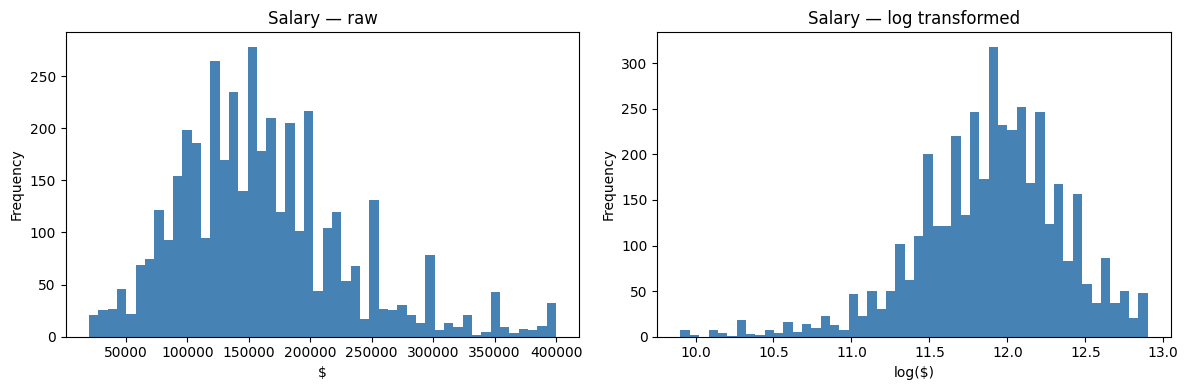

0.8774741758659096
-0.6892119327530632


In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["salary"].plot.hist(bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Salary — raw")
axes[0].set_xlabel("$")

np.log(df["salary"]).plot.hist(bins=50, ax=axes[1], color="steelblue")
axes[1].set_title("Salary — log transformed")
axes[1].set_xlabel("log($)")

plt.tight_layout()
plt.show()

print(df["salary"].skew())          # raw skewness
print(np.log(df["salary"]).skew())  # log skewness

In [14]:
print(df.columns.tolist())
print(df[["org_size", "remote_work"]].head())

['salary', 'years_code', 'work_exp', 'log_work_exp', 'education', 'org_size', 'remote_work', 'is_manager', 'is_fullstack', 'is_backend', 'is_frontend', 'is_ml', 'is_devops', 'is_mobile', 'lang_python', 'lang_rust', 'lang_go', 'lang_typescript', 'lang_kotlin', 'lang_scala', 'lang_swift', 'cloud_aws', 'cloud_azure', 'cloud_gcp', 'web_react', 'web_nextjs', 'web_fastapi', 'web_django', 'uses_ai_tools']
    org_size  remote_work
22       4.0          2.0
29       5.0          2.0
31       4.0          2.0
33       7.0          1.0
37       8.0          0.0


In [18]:
# ═══════════════════════════════════════════════════════════════
# STAGE 4 — FEATURE ENGINEERING
# ═══════════════════════════════════════════════════════════════


# Cap work_exp at 40 years — anything above is a bad survey response
df["work_exp"] = df["work_exp"].clip(upper=40)

# Verify
print(df["work_exp"].describe())


# ── 1. Log-transform the target ───────────────────────────────
# We'll train on log_salary and convert predictions back with exp()
df["log_salary"] = np.log(df["salary"])

print("salary      mean:", df["salary"].mean().round(0))
print("log_salary  mean:", df["log_salary"].mean().round(3))
# log_salary mean ~11.9 = exp(11.9) ≈ $147k — that's our baseline

# ── 2. Experience squared ─────────────────────────────────────
# Captures diminishing returns on experience
df["work_exp_sq"] = df["work_exp"] ** 2

# Quick check — does squaring spread the values out?
print("\nwork_exp    range:", df["work_exp"].min(), "–", df["work_exp"].max())
print("work_exp_sq range:", df["work_exp_sq"].min(), "–", df["work_exp_sq"].max())

# ── 3. Breadth features ───────────────────────────────────────
# How many cloud platforms does this person know?
df["n_cloud"] = df["cloud_aws"] + df["cloud_azure"] + df["cloud_gcp"]

# How many high-value languages do they know?
# (excluding Python — it's too common to be a differentiator)
df["n_hv_langs"] = (df["lang_rust"] + df["lang_go"] +
                    df["lang_typescript"] + df["lang_kotlin"] + df["lang_scala"])

# How many web frameworks?
df["n_webframes"] = df["web_react"] + df["web_nextjs"] + df["web_fastapi"] + df["web_django"]

print("\nn_cloud     value counts:\n", df["n_cloud"].value_counts().sort_index())
print("\nn_hv_langs  value counts:\n", df["n_hv_langs"].value_counts().sort_index())

# ── 4. Interaction terms ──────────────────────────────────────
# Experience × Education
# A Master's with 1 year exp ≠ a Master's with 15 years exp
df["exp_x_edu"] = df["work_exp"] * df["education"]

# Experience × Org size
# Senior people at large companies earn disproportionately more
df["exp_x_orgsize"] = df["work_exp"] * df["org_size"]

# Manager × Experience
# Junior managers don't earn much more — the premium grows with experience
df["manager_x_exp"] = df["is_manager"] * df["work_exp"]

# ML role × Cloud breadth
# A data scientist who also knows cloud infra earns more than one who doesn't
df["ml_x_cloud"] = df["is_ml"] * df["n_cloud"]

# ── 5. Final check ────────────────────────────────────────────
feature_cols = [c for c in df.columns if c not in ["salary", "log_salary"]]

print("\nTotal features:", len(feature_cols))
print("Feature list:\n", feature_cols)
print("\nSample with new features:")
print(df[["salary", "log_salary", "work_exp_sq",
          "n_cloud", "n_hv_langs", "exp_x_edu",
          "exp_x_orgsize", "manager_x_exp", "ml_x_cloud"]].head(5))

# ── 6. Save cleaned data ──────────────────────────────────────
df.to_csv("C:\\Users\\User\\Desktop\\developer survey ML project\\data\\survey_cleaned.csv", index=False)
print("\nSaved → data/survey_cleaned.csv")
print("Shape saved:", df.shape)

count    4149.000000
mean       15.928899
std        10.420823
min         1.000000
25%         8.000000
50%        14.000000
75%        24.000000
max        40.000000
Name: work_exp, dtype: float64
salary      mean: 161149.0
log_salary  mean: 11.891

work_exp    range: 1.0 – 40.0
work_exp_sq range: 1.0 – 1600.0

n_cloud     value counts:
 n_cloud
0    1646
1    2069
2     434
Name: count, dtype: int64

n_hv_langs  value counts:
 n_hv_langs
0    1547
1    1618
2     692
3     235
4      51
5       6
Name: count, dtype: int64

Total features: 36
Feature list:
 ['years_code', 'work_exp', 'log_work_exp', 'education', 'org_size', 'remote_work', 'is_manager', 'is_fullstack', 'is_backend', 'is_frontend', 'is_ml', 'is_devops', 'is_mobile', 'lang_python', 'lang_rust', 'lang_go', 'lang_typescript', 'lang_kotlin', 'lang_scala', 'lang_swift', 'cloud_aws', 'cloud_azure', 'cloud_gcp', 'web_react', 'web_nextjs', 'web_fastapi', 'web_django', 'uses_ai_tools', 'work_exp_sq', 'n_cloud', 'n_hv_langs', 'n